# Real World Classification

## Load data

Import the necessary libraries

In [2]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [4]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [5]:
# Q3(a): Report the median and standard deviation for columns with missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}\n")

print("=== Q3(a): Before Imputation ===")
for col in missing_cols:
    med = df[col].median()
    std = df[col].std()
    n_missing = df[col].isnull().sum()
    print(f"{col}: median={med:.4f}, std={std:.4f}, missing_count={n_missing}")

Columns with missing values: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

=== Q3(a): Before Imputation ===
SepalLengthCm: median=6.3000, std=1.0371, missing_count=28
SepalWidthCm: median=2.9000, std=0.3896, missing_count=57
PetalLengthCm: median=5.0856, std=1.5828, missing_count=150
PetalWidthCm: median=1.6000, std=0.7067, missing_count=22
BranchLength: median=16.3000, std=1.0352, missing_count=24


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using "Nearest Neighbors Imputation"
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [7]:
# Q3(b): Report the median and standard deviation after KNN Imputation
print("=== Q3(b): After KNN Imputation ===")
for col in missing_cols:
    med = df[col].median()
    std = df[col].std()
    n_missing = df[col].isnull().sum()
    print(f"{col}: median={med:.4f}, std={std:.4f}, missing_count={n_missing}")

print("\n=== Comparison (Before vs After) ===")
print(f"{'Column':<20} {'Median (Before)':>16} {'Median (After)':>16} {'Std (Before)':>14} {'Std (After)':>14}")
print("-" * 84)
# Re-read original data for comparison
df_orig = pd.read_csv('data/NYCU_Iris.csv')
for col in missing_cols:
    df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')
    med_before = df_orig[col].median()
    std_before = df_orig[col].std()
    med_after = df[col].median()
    std_after = df[col].std()
    print(f"{col:<20} {med_before:>16.4f} {med_after:>16.4f} {std_before:>14.4f} {std_after:>14.4f}")

=== Q3(b): After KNN Imputation ===
SepalLengthCm: median=6.3000, std=1.0093, missing_count=0
SepalWidthCm: median=2.9000, std=0.3724, missing_count=0
PetalLengthCm: median=5.0357, std=1.5150, missing_count=0
PetalWidthCm: median=1.7000, std=0.6946, missing_count=0
BranchLength: median=16.3000, std=1.0110, missing_count=0

=== Comparison (Before vs After) ===
Column                Median (Before)   Median (After)   Std (Before)    Std (After)
------------------------------------------------------------------------------------
SepalLengthCm                  6.3000           6.3000         1.0371         1.0093
SepalWidthCm                   2.9000           2.9000         0.3896         0.3724
PetalLengthCm                  5.0856           5.0357         1.5828         1.5150
PetalWidthCm                   1.6000           1.7000         0.7067         0.6946
BranchLength                  16.3000          16.3000         1.0352         1.0110


In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

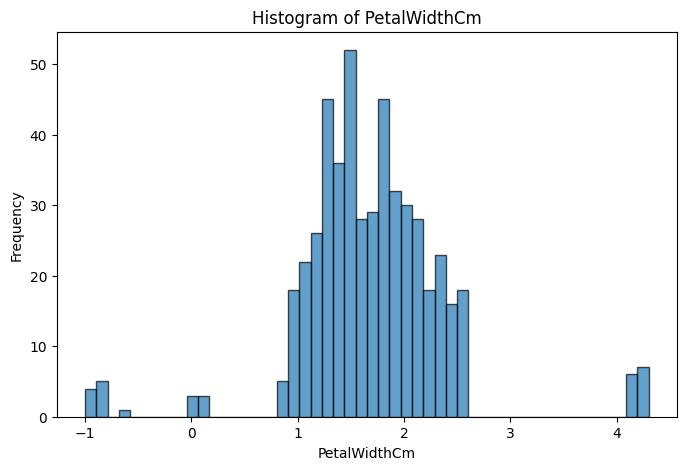

=== Q4(b): Largest Positive Correlation with PetalWidthCm ===
PetalWidthCompactness: r = 0.9917

=== Q4(c): Top 5 Strongest Negative Correlations with PetalWidthCm ===
SepalWidthMajorAxis: r = -0.0964
SepalGlossIndex: r = -0.0952
SepalWidthCompactness: r = -0.0885
SepalWidthCurvature: r = -0.0813
SepalWidthMinorAxis: r = -0.0744

=== Q4(d): Boxplot features ===
['PetalWidthCompactness', 'SepalWidthMajorAxis', 'SepalGlossIndex', 'SepalWidthCompactness', 'SepalWidthCurvature', 'SepalWidthMinorAxis']


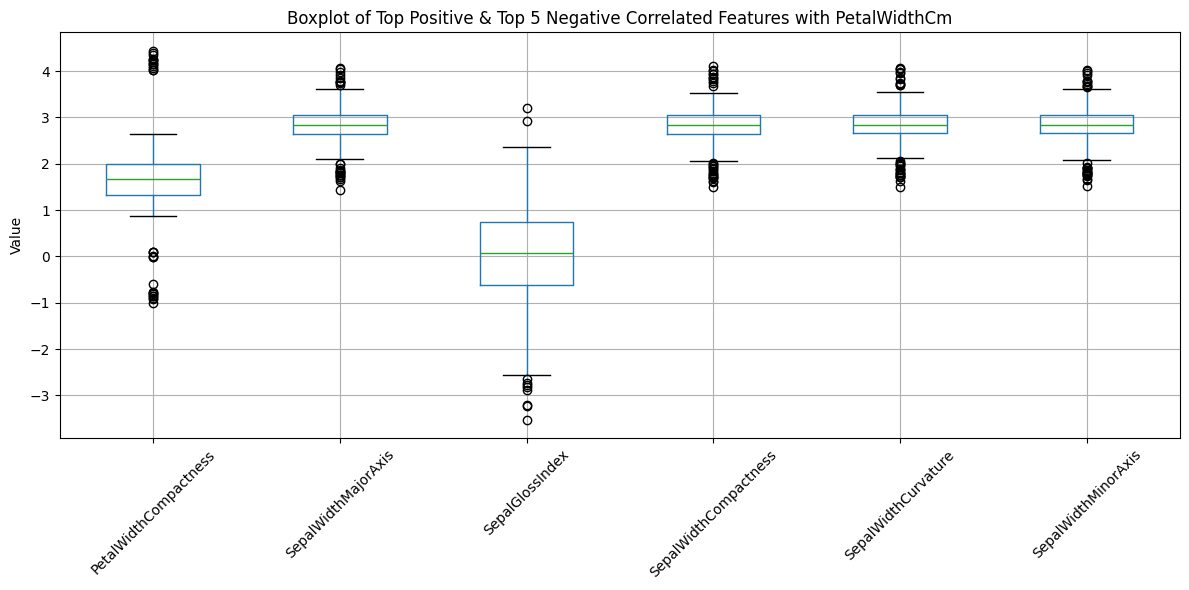

In [9]:
import os
from sklearn.feature_selection import r_regression

os.makedirs('Chart', exist_ok=True)

# ============================================================
# Q4(a): Plot the histogram of PetalWidthCm
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['PetalWidthCm'], bins=50, edgecolor='black', alpha=0.7)
ax.set_title('Histogram of PetalWidthCm')
ax.set_xlabel('PetalWidthCm')
ax.set_ylabel('Frequency')
fig.savefig('Chart/Q4a_PetalWidthCm_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Q4(b): Feature with largest positive Pearson correlation
# ============================================================
exclude_cols = ['PetalWidthCm', 'Species', 'Id']
corr_features = [c for c in df.columns if c not in exclude_cols]

X_corr = df[corr_features].values
y_corr = df['PetalWidthCm'].values

# r_regression returns Pearson correlation for each feature vs target
correlations = r_regression(X_corr, y_corr)
corr_series = pd.Series(correlations, index=corr_features)

# Largest positive correlation
top_positive = corr_series.idxmax()
print(f"=== Q4(b): Largest Positive Correlation with PetalWidthCm ===")
print(f"{top_positive}: r = {corr_series[top_positive]:.4f}")

# ============================================================
# Q4(c): Top 5 features with strongest negative correlations
# ============================================================
top5_negative = corr_series.nsmallest(5)
print(f"\n=== Q4(c): Top 5 Strongest Negative Correlations with PetalWidthCm ===")
for feat, r_val in top5_negative.items():
    print(f"{feat}: r = {r_val:.4f}")

# ============================================================
# Q4(d): Boxplot for all features from 4(b) and 4(c)
# ============================================================
boxplot_features = [top_positive] + top5_negative.index.tolist()
print(f"\n=== Q4(d): Boxplot features ===")
print(boxplot_features)

fig, ax = plt.subplots(figsize=(12, 6))
df[boxplot_features].boxplot(ax=ax, rot=45)
ax.set_title('Boxplot of Top Positive & Top 5 Negative Correlated Features with PetalWidthCm')
ax.set_ylabel('Value')
plt.tight_layout()
fig.savefig('Chart/Q4d_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Training

### Prepare the data

In [10]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!


Setting: No Regularization
50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177569
200. Training loss: 0.5636439627476498, Val loss:0.6019785825360591
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.58077162665673
450. Training loss: 0.5185712433977273, Val loss:0.5778662753932695
500. Training loss: 0.5127496761323889, Val loss:0.5755614147648992
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.491

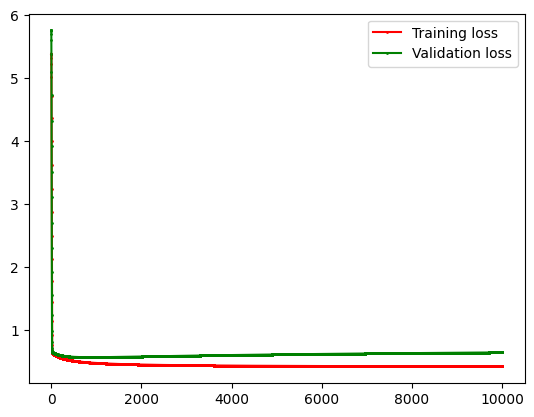

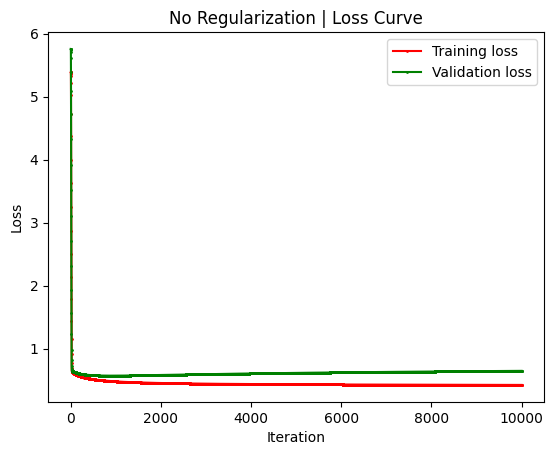

Sum of absolute values of weights: 59.6665
No Regularization
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


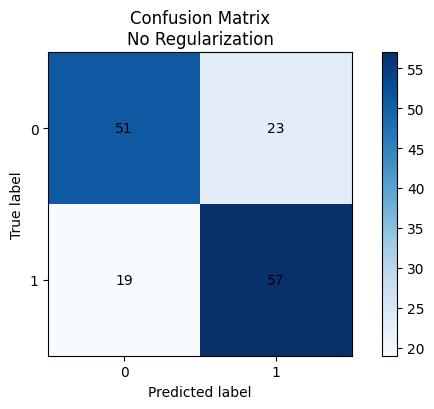



Setting: L2 (reg_lambda=0.01)
50. Training loss: 0.6183968442308058, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.563685266911725, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456717, Val loss:0.5947528491389575
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451083
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412458
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950175
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452544
550. Training loss: 0.5076902593666242, Val loss:0.5737553335810299
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402411
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888322
750. Training loss

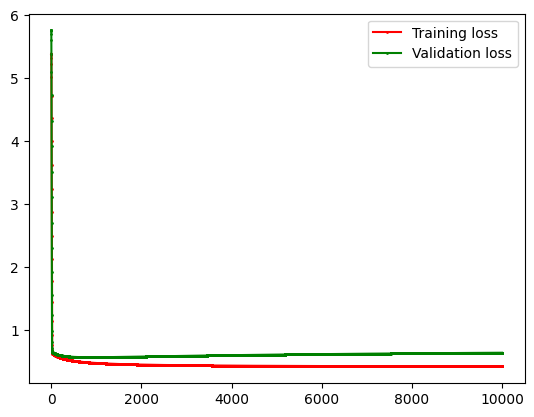

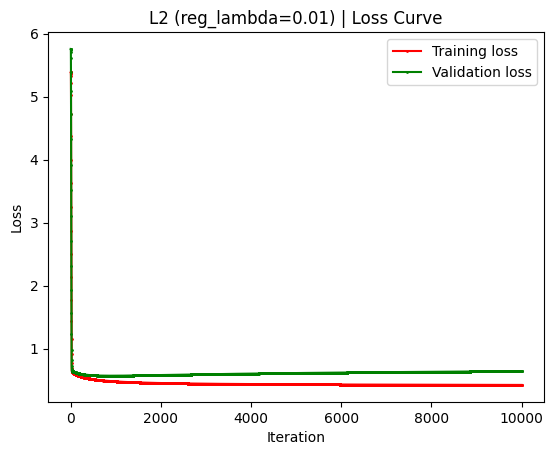

Sum of absolute values of weights: 58.2757
L2 (reg_lambda=0.01)
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


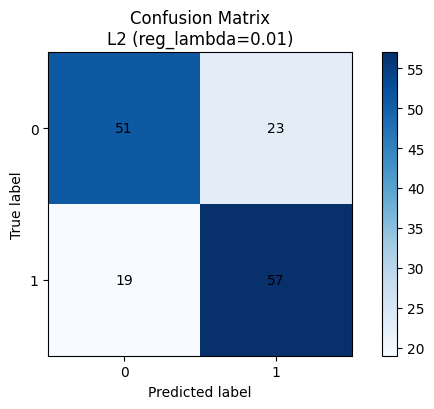



Setting: L2 (reg_lambda=1)
50. Training loss: 0.6192229675550639, Val loss:0.6387339171797572
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.6126225576568589
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908267
250. Training loss: 0.5571858255876309, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871132
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364932
500. Training loss: 0.524460662779445, Val loss:0.5791436781671646
550. Training loss: 0.5204280628046019, Val loss:0.577342251554659
600. Training loss: 0.5169056942810415, Val loss:0.5758788683267104
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.511079702784841, Val loss:0.5737215545999529
750. Training loss: 0.50865

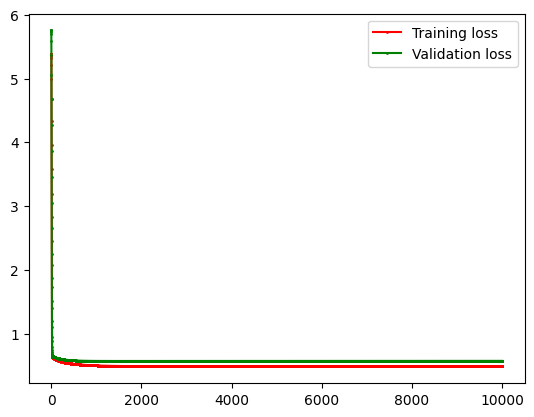

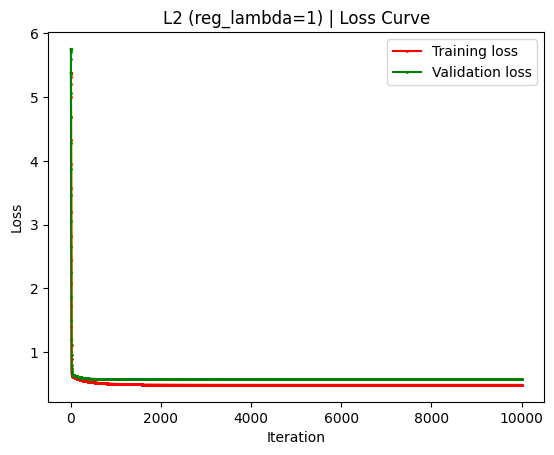

Sum of absolute values of weights: 24.6866
L2 (reg_lambda=1)
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


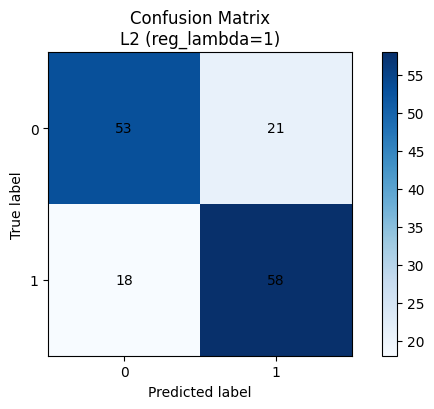



Setting: L2 (reg_lambda=100)
50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460088
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693629
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0

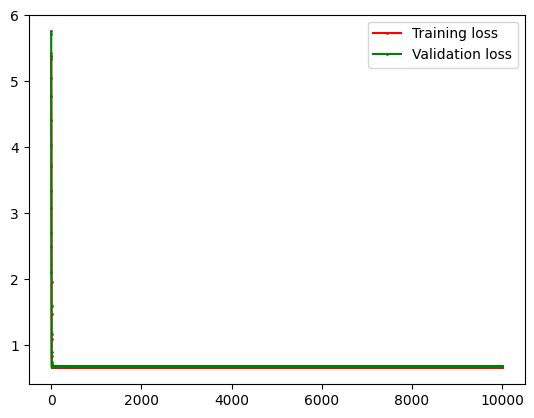

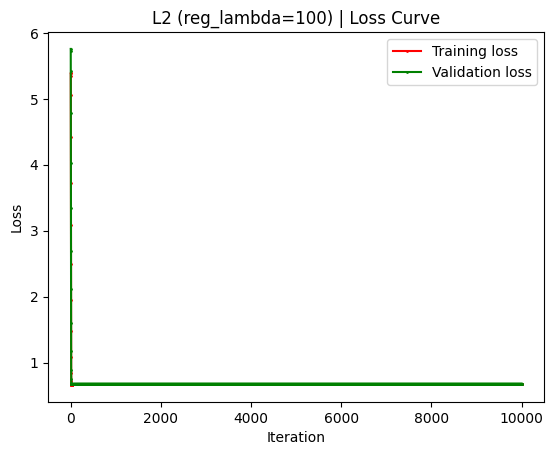

Sum of absolute values of weights: 0.9552
L2 (reg_lambda=100)
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


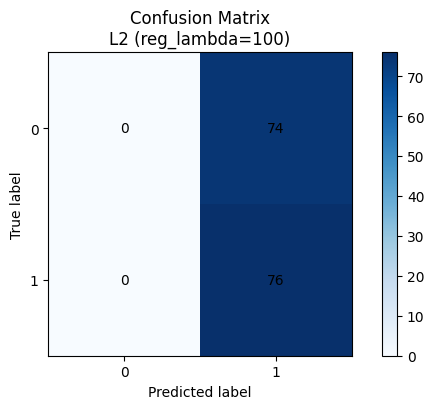

In [11]:
# Q5: Regularization Comparison
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Settings: (label, reg_type, reg_lambda)
settings = [
    ('No Regularization', '', 0.0),
    ('L2 (reg_lambda=0.01)', 'l2', 0.01),
    ('L2 (reg_lambda=1)', 'l2', 1.0),
    ('L2 (reg_lambda=100)', 'l2', 100.0),
]

for label, reg_type, reg_lambda in settings:
    print(f"\n{'='*60}")
    print(f"Setting: {label}")
    print(f"{'='*60}")

    np.random.seed(seed)
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type=reg_type, reg_lambda=reg_lambda)
    plt.close('all')  # close the untitled inline loss plot from model.fit

    # Re-plot loss curve with title and save
    fig, ax = plt.subplots()
    ax.set_title(f'{label} | Loss Curve')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.plot(range(len(model.train_losses)), model.train_losses, 'o-', color='r', label='Training loss', markersize=1)
    ax.plot(range(len(model.val_losses)), model.val_losses, 'o-', color='g', label='Validation loss', markersize=1)
    ax.legend(loc='best')
    save_name = label.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
    fig.savefig(f'Chart/Q5_{save_name}_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print model weight info
    print(f"Sum of absolute values of weights: {np.sum(np.abs(model.W)):.4f}")

    # Evaluation on test set
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(
        y_test, y_pred,
        title=f'{label}',
        save_path=f'Chart/Q5_{save_name}_confusion_matrix.png'
    )
    print()

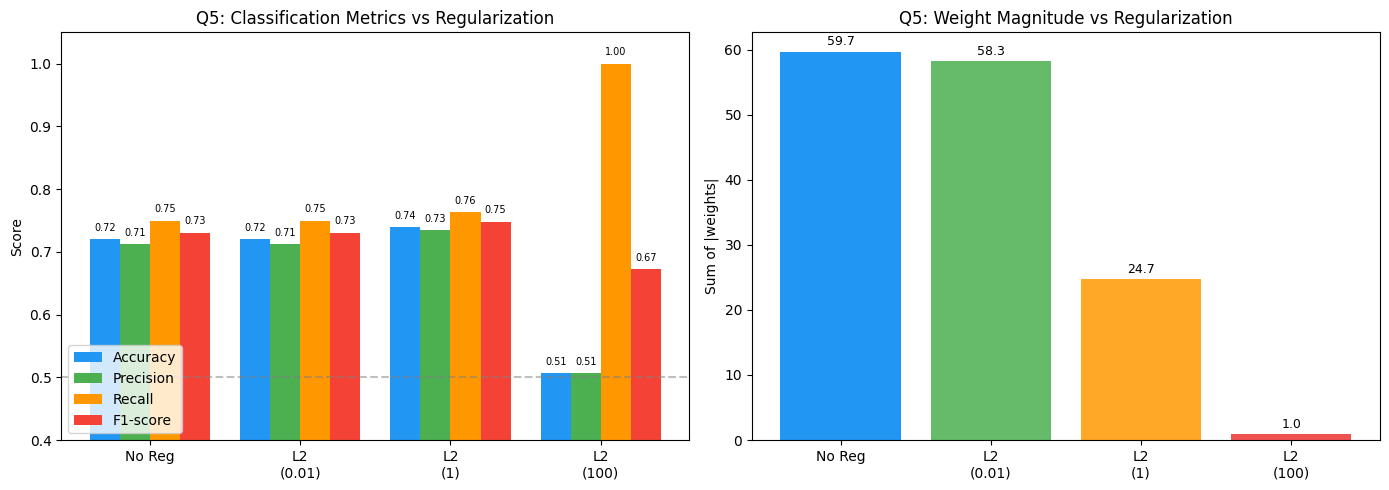

In [12]:
# Q5: Visual Comparison of Regularization Results
import matplotlib.pyplot as plt
import numpy as np

labels = ['No Reg', 'L2\n(0.01)', 'L2\n(1)', 'L2\n(100)']
accuracy  = [0.7200, 0.7200, 0.7400, 0.5067]
precision = [0.7125, 0.7125, 0.7342, 0.5067]
recall    = [0.7500, 0.7500, 0.7632, 1.0000]
f1        = [0.7308, 0.7308, 0.7484, 0.6726]
weight_sum = [59.6665, 58.2757, 24.6866, 0.9552]

x = np.arange(len(labels))
width = 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Metrics comparison
bars1 = ax1.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='#2196F3')
bars2 = ax1.bar(x - 0.5*width, precision, width, label='Precision', color='#4CAF50')
bars3 = ax1.bar(x + 0.5*width, recall,    width, label='Recall',    color='#FF9800')
bars4 = ax1.bar(x + 1.5*width, f1,        width, label='F1-score',  color='#F44336')

ax1.set_ylabel('Score')
ax1.set_title('Q5: Classification Metrics vs Regularization')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0.4, 1.05)
ax1.legend(loc='lower left')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7)

# Right: Weight magnitude
ax2.bar(x, weight_sum, color=['#2196F3', '#66BB6A', '#FFA726', '#EF5350'])
ax2.set_ylabel('Sum of |weights|')
ax2.set_title('Q5: Weight Magnitude vs Regularization')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
for i, v in enumerate(weight_sum):
    ax2.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig('Chart/Q5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177569
200. Training loss: 0.5636439627476498, Val loss:0.6019785825360591
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.588991764914238
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.58077162665673
450. Training loss: 0.5185712433977273, Val loss:0.5778662753932695
500. Training loss: 0.5127496761323889, Val loss:0.5755614147648992
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860386
750. Training loss: 0.4915237794843891, Val loss:0.56

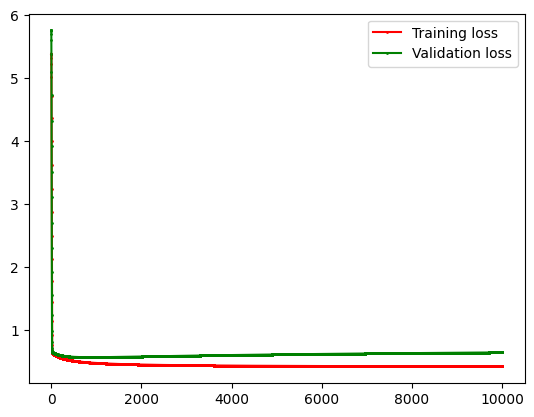

50. Training loss: 0.6183968442308058, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.563685266911725, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456717, Val loss:0.5947528491389575
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451083
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412458
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950175
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452544
550. Training loss: 0.5076902593666242, Val loss:0.5737553335810299
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402411
650. Training loss: 0.4988935840888995, Val loss:0.5712557548145529
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888322
750. Training loss: 0.4916810781087383, Val loss:0

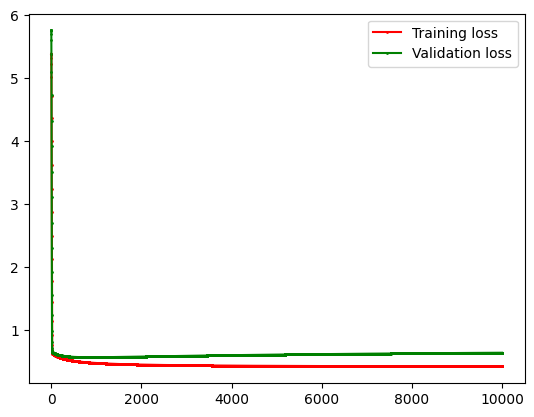

50. Training loss: 0.6192229675550639, Val loss:0.6387339171797572
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.6126225576568589
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908267
250. Training loss: 0.5571858255876309, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871132
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364932
500. Training loss: 0.524460662779445, Val loss:0.5791436781671646
550. Training loss: 0.5204280628046019, Val loss:0.577342251554659
600. Training loss: 0.5169056942810415, Val loss:0.5758788683267104
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.511079702784841, Val loss:0.5737215545999529
750. Training loss: 0.5086569127317132, Val loss:0.57293

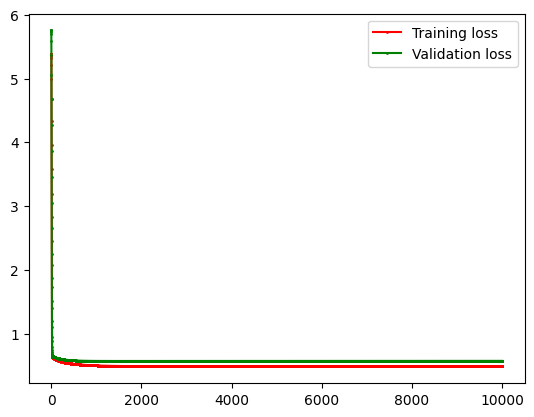

50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460088
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693629
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.6747487179829382, Val loss:0.6

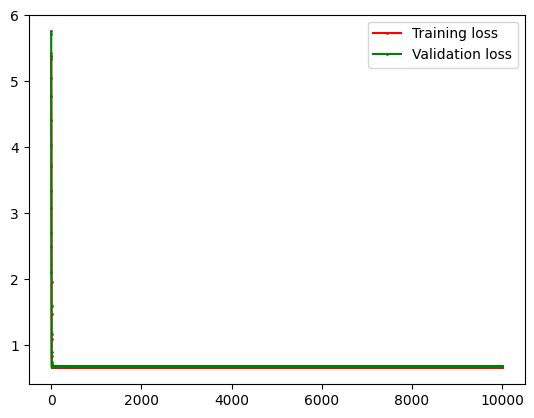

L2 Norms of weight vectors:
  No Reg (λ=0): ||W||₂ = 9.1445
  L2 (λ=0.01): ||W||₂ = 8.9302
  L2 (λ=1): ||W||₂ = 3.6437
  L2 (λ=100): ||W||₂ = 0.1428


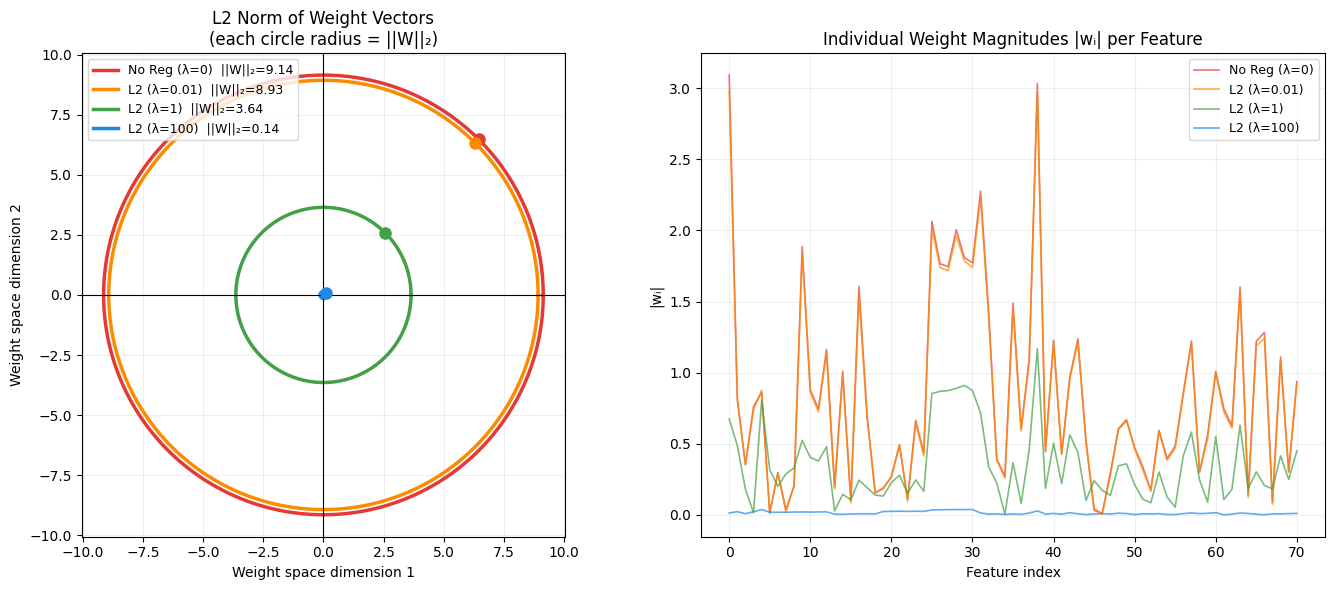

Saved: Chart/Q5_L2_geometric_interpretation.png


In [13]:
# Q5: Geometric Interpretation — L2 Norm of Weights under Different Lambda
# Visualize how the L2 constraint shrinks the weight vector toward the origin

import matplotlib.pyplot as plt
import numpy as np

# --- Re-train all 4 settings and collect the weight vectors ---
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

settings = [
    ('No Reg (λ=0)',       '', 0.0),
    ('L2 (λ=0.01)',      'l2', 0.01),
    ('L2 (λ=1)',         'l2', 1.0),
    ('L2 (λ=100)',       'l2', 100.0),
]

weight_vectors = []
weight_norms = []
labels_list = []

for label, reg_type, reg_lambda in settings:
    np.random.seed(seed)
    model = LinearModel(dim=X_train.shape[1], is_reg=False,
                        loss_fn=logloss, act_fn=sigmoid, grad_fn=logloss_sigmoid_grad)
    model.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2,
              reg_type=reg_type, reg_lambda=reg_lambda)
    plt.close('all')

    weight_vectors.append(model.W.copy())
    weight_norms.append(np.sqrt(np.sum(model.W ** 2)))  # L2 norm
    labels_list.append(label)

print("L2 Norms of weight vectors:")
for lbl, norm in zip(labels_list, weight_norms):
    print(f"  {lbl}: ||W||₂ = {norm:.4f}")

# ============================================================
# Plot 1: L2 Norm circles — each experiment's weight norm shown as a circle
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']
theta = np.linspace(0, 2 * np.pi, 200)

for i, (lbl, norm) in enumerate(zip(labels_list, weight_norms)):
    x_circle = norm * np.cos(theta)
    y_circle = norm * np.sin(theta)
    ax1.plot(x_circle, y_circle, color=colors[i], linewidth=2.5, label=f'{lbl}  ||W||₂={norm:.2f}')
    # Mark a point on the circle (at 45°) to show the "tip" of the weight vector
    ax1.plot(norm * np.cos(np.pi/4), norm * np.sin(np.pi/4), 'o',
             color=colors[i], markersize=8, zorder=5)

ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_aspect('equal')
ax1.set_title('L2 Norm of Weight Vectors\n(each circle radius = ||W||₂)', fontsize=12)
ax1.set_xlabel('Weight space dimension 1', fontsize=10)
ax1.set_ylabel('Weight space dimension 2', fontsize=10)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.2)

# ============================================================
# Plot 2: Weight distribution comparison — show individual weight magnitudes
# ============================================================
n_features = len(weight_vectors[0])
x_pos = np.arange(n_features)

for i, (lbl, W) in enumerate(zip(labels_list, weight_vectors)):
    ax2.plot(x_pos, np.abs(W), color=colors[i], alpha=0.7, linewidth=1.2, label=lbl)

ax2.set_title('Individual Weight Magnitudes |wᵢ| per Feature', fontsize=12)
ax2.set_xlabel('Feature index', fontsize=10)
ax2.set_ylabel('|wᵢ|', fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig('Chart/Q5_L2_geometric_interpretation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Chart/Q5_L2_geometric_interpretation.png")